In [16]:
# %%
# Imports and configuration
# TS2Vec (pretrain on all sequences) → pooled embeddings → LightGBM (+ metadata)
#
# This cell-block performs unsupervised pretraining with TS2Vec on **all** available
# temporal sequences (train+val+test), computes instance-level embeddings (pooled
# "full_series" representations), concatenates them with metadata features, and
# trains a LightGBM classifier. The workflow mirrors your previous MiniRocket pipeline
# so evaluation, per-baby F1, calibration curve and SHAP explanations are also produced.
#
# Requirements: pip install ts2vec torch lightgbm scikit-learn pandas numpy joblib shap (optional)
# Official TS2Vec repository / package: zhihanyue/ts2vec (README usage). citeturn2view0turn0search2

import os
import sys
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef)

warnings.filterwarnings("ignore")

# Function to find project root
# exit if not found
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)
try:
    sys.path.append(PROJECT_ROOT)
    print("Added project root to sys.path.")
except Exception as e:
    print("Failed to add project root to sys.path:", e)
    sys.exit(1)

from config import settings
import config_ts2vec as conf
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
from _utils_ import dataset_utils
print("Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).")
USE_PROJECT_UTILS = True

# Paths: if utils is available, use its helper; otherwise set manual paths
if USE_PROJECT_UTILS:
    TRAIN_PATH = settings.get_dataset_path(conf.dataset_type, settings.train_filename)
    VAL_PATH = settings.get_dataset_path(conf.dataset_type, settings.validation_filename)
    TEST_PATH = settings.get_dataset_path(conf.dataset_type, settings.test_filename)
else:
    TRAIN_PATH = ""
    VAL_PATH = ""
    TEST_PATH = ""

OUT_DIR = Path("./results_ts2vec_lightgbm")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# TS2Vec & LightGBM
try:
    from ts2vec import TS2Vec
except Exception as e:
    raise ImportError("ts2vec package not found. Install with: pip install ts2vec")

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
except Exception:
    raise ImportError('lightgbm not found. Install with: pip install lightgbm')

try:
    import torch
except Exception:
    raise ImportError('torch not found. Install a compatible torch version (see ts2vec README).')

try:
    import shap
except Exception:
    shap = None


Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Added project root to sys.path.
Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).


# Helper

In [17]:
# convert BoaOpenFaceDataset -> X array [N, C, L] and y array [N]
# Then we'll transpose to [N, L, C] for TS2Vec

def ds_to_numpy_CxL(ds, modalities=None):
    modality_map = {
        'g': 'gaze_info',
        'h': 'head_info',
        'f': 'face_info'
    }
    if modalities is None:
        modalities = ds.modalities if hasattr(ds, 'modalities') else ['g','h','f']
    X_list, y_list = [], []
    keys = []
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map.get(m)
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        X_list.append(X.T)  # [D_tot, L]
        y_list.append(int(inst.trial_type))
        keys.append((str(inst.pt_id), int(inst.trial_id)))
    X_arr = np.stack(X_list, axis=0)  # [N, C, L]
    y_arr = np.array(y_list)
    return X_arr, y_arr, keys

In [18]:
# Load datasets (reuse paths from earlier)
print('Loading datasets for TS2Vec pretraining...')
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH)

# Build metadata DataFrames (reuse dataset_to_metadata_df if present)
if 'dataset_to_metadata_df' in globals():
    df_train = dataset_utils.dataset_to_metadata_df(train_ds)
    df_val = dataset_utils.dataset_to_metadata_df(val_ds)
    df_test = dataset_utils.dataset_to_metadata_df(test_ds)
else:
    def simple_meta(ds):
        rows = []
        for inst in ds.instances:
            rows.append({
                'pt_id': inst.pt_id,
                'trial_id': inst.trial_id,
                'label': int(inst.trial_type),
                'age': float(inst.age) if inst.age is not None else np.nan,
                'sex': inst.sex if inst.sex is not None else np.nan,
                'audio': inst.audio if hasattr(inst, 'audio') else None,
                'speaker': inst.speaker if hasattr(inst, 'speaker') else None,
                'duration_s': inst.face_info.shape[0] / ds.FRAME_RATE if hasattr(inst, 'face_info') else np.nan,
            })
        return pd.DataFrame(rows)
    df_train = simple_meta(train_ds)
    df_val = simple_meta(val_ds)
    df_test = simple_meta(test_ds)

# Drop rows without labels
for df in (df_train, df_val, df_test):
    df.dropna(subset=['label'], inplace=True)

# Preprocessor for metadata (same as earlier)
numeric_features = ["age", "duration_s"]
cat_features = ["sex"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
cat_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', cat_transformer, cat_features)])
preprocessor.fit(df_train[numeric_features + cat_features])
X_meta_train = preprocessor.transform(df_train[numeric_features + cat_features])
X_meta_val = preprocessor.transform(df_val[numeric_features + cat_features])
X_meta_test = preprocessor.transform(df_test[numeric_features + cat_features])

Loading datasets for TS2Vec pretraining...


In [19]:
# Prepare temporal arrays for TS2Vec: [N, L, C]
selected_modalities = train_ds.modalities if hasattr(train_ds, 'modalities') else ['g','h','f']
X_train_ts, y_train, keys_train = ds_to_numpy_CxL(train_ds, modalities=selected_modalities)
X_val_ts, y_val, keys_val = ds_to_numpy_CxL(val_ds, modalities=selected_modalities)
X_test_ts, y_test, keys_test = ds_to_numpy_CxL(test_ds, modalities=selected_modalities)

# transpose to [N, L, C]
X_train_ts_t = np.transpose(X_train_ts, (0, 2, 1)).astype(np.float32)
X_val_ts_t = np.transpose(X_val_ts, (0, 2, 1)).astype(np.float32)
X_test_ts_t = np.transpose(X_test_ts, (0, 2, 1)).astype(np.float32)

print('Temporal shapes (N, L, C):', X_train_ts_t.shape, X_val_ts_t.shape, X_test_ts_t.shape)

Temporal shapes (N, L, C): (619, 250, 38) (140, 250, 38) (137, 250, 38)


Pretraining TS2Vec on all sequences: (896, 250, 38)
Fitting TS2Vec...
Epoch #0: loss=4.364655490432467
Epoch #1: loss=2.2769621653216228
Epoch #2: loss=1.9645444239888872
Epoch #3: loss=1.6810509434768133
Epoch #4: loss=1.354898220726422
Epoch #5: loss=1.1726310104131699
Epoch #6: loss=1.0137680183563913
Epoch #7: loss=1.0462090160165514
Epoch #8: loss=0.9105945740427289
Epoch #9: loss=0.83702773387943
Epoch #10: loss=0.8364719886864934
Epoch #11: loss=0.7372693408812795
Epoch #12: loss=0.742493140910353
Epoch #13: loss=0.7101664724094527
Epoch #14: loss=0.7049720585346222
Epoch #15: loss=0.6749156569795949
Epoch #16: loss=0.6844821934189115
Epoch #17: loss=0.6044045170503003
Epoch #18: loss=0.5607346642230239
Epoch #19: loss=0.6475937552750111
Epoch #20: loss=0.5277946282710347
Epoch #21: loss=0.5204262781356063
Epoch #22: loss=0.46886626364929335
Epoch #23: loss=0.5565718114376068
Epoch #24: loss=0.4951971151999065
Epoch #25: loss=0.6019854779754367
Epoch #26: loss=0.5457506967442376

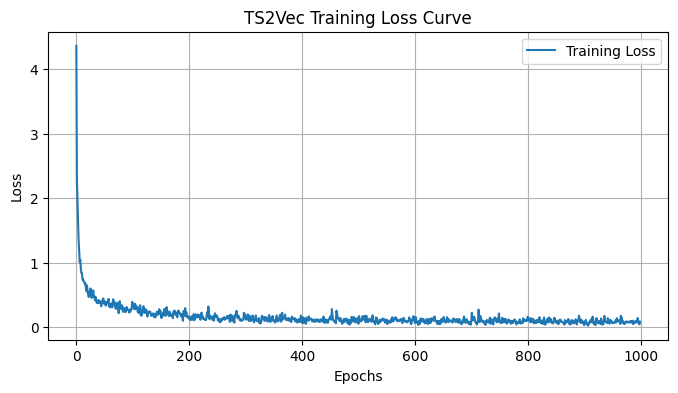

In [33]:
# Pretrain TS2Vec on ALL sequences (train+val+test) -- unsupervised pretraining
all_ts = np.concatenate([X_train_ts_t, X_val_ts_t, X_test_ts_t], axis=0).astype(np.float32)
print('Pretraining TS2Vec on all sequences:', all_ts.shape)

# Choose device: use GPU if available, otherwise fall back to CPU-compatible flag for TS2Vec
if torch.cuda.is_available():
    device = 0
else:
    # The TS2Vec implementation accepts -1 for CPU in many forks; try -1, fallback to 'cpu'
    device = -1

repr_dims = 512  # representation dimensionality (tuneable)
model = TS2Vec(input_dims=X_train_ts_t.shape[2], device=device, output_dims=repr_dims)

# Fit the model and plot the loss curve
print('Fitting TS2Vec...')
loss_log = model.fit(all_ts, verbose=True, n_epochs=1000)

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_log, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('TS2Vec Training Loss Curve')
plt.legend()
plt.grid()
plt.show()



In [27]:
# Encode instance-level representations (full_series) for each split
emb_train = model.encode(X_train_ts_t, encoding_window='full_series')  # [N_train, repr_dims]
emb_val = model.encode(X_val_ts_t, encoding_window='full_series')
emb_test = model.encode(X_test_ts_t, encoding_window='full_series')

print('Embeddings shapes:', emb_train.shape, emb_val.shape, emb_test.shape)

Embeddings shapes: (619, 320) (140, 320) (137, 320)


In [43]:
# Check class distribution
from collections import Counter
print("Train label counts:", Counter(y_train))
print("Val label counts:", Counter(y_val))
print("Test label counts:", Counter(y_test))

Train label counts: Counter({1: 497, 0: 122})
Val label counts: Counter({1: 112, 0: 28})
Test label counts: Counter({1: 110, 0: 27})


# LightGBM Head

In [83]:
# Concatenate embeddings with metadata and train LightGBM
X_train_all = np.hstack([emb_train, X_meta_train])
X_val_all = np.hstack([emb_val, X_meta_val])
X_test_all = np.hstack([emb_test, X_meta_test])

pos = (y_train==1).sum()
neg = (y_train==0).sum()
clf = LGBMClassifier(random_state=0, n_jobs=-1, class_weight=None,
                     scale_pos_weight = neg / max(1, pos),
                     n_estimators=1000, learning_rate=0.05)
clf.fit(X_train_all, y_train, eval_set=[(X_val_all, y_val)])

# Find best threshold on validation set
probs_val = clf.predict_proba(X_val_all)[:, 1]
best_thr = 0.5
best_bal = 0.0
for thr in np.linspace(0, 1, 101):
    preds = (probs_val >= thr).astype(int)
    bal = balanced_accuracy_score(y_val, preds)
    if bal > best_bal:
        best_bal = bal
        best_thr = thr
print(f'Best threshold on VAL: {best_thr:.2f} (bal_acc={best_bal:.4f})')


[LightGBM] [Info] Number of positive: 497, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 66286
[LightGBM] [Info] Number of data points in the train set: 619, number of used features: 323
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.802908 -> initscore=1.404569
[LightGBM] [Info] Start training from score 1.404569
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

TEST balanced accuracy (thr=0.99): 0.4286
TEST Matthews correlation coefficient (thr=0.99): -0.1290
Per-baby F1 (test) — showing all babies with >=2 samples:
      pt_id  n_samples        f1
2  bam1_018         20  0.571429
3  bam1_020         20  0.666667
5  bam1_026         20  0.750000
0  bam1_005         20  0.758621
1  bam1_008         18  0.800000
4  bam1_024         19  0.800000
6  bam1_044         20  0.812500
Test classification report:
              precision    recall  f1-score   support

           0     0.1111    0.1481    0.1270        27
           1     0.7723    0.7091    0.7393       110

    accuracy                         0.5985       137
   macro avg     0.4417    0.4286    0.4332       137
weighted avg     0.6420    0.5985    0.6187       137



<Figure size 500x400 with 0 Axes>

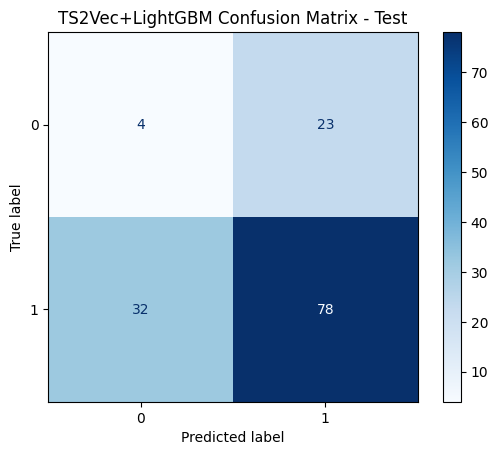

Saved TS2Vec+LightGBM state to results_ts2vec_lightgbm/ts2vec_lightgbm_state.joblib


In [84]:
# Evaluate on TEST set
probs_test = clf.predict_proba(X_test_all)[:, 1]
y_pred_test = (probs_test >= best_thr).astype(int)

bal_test = balanced_accuracy_score(y_test, y_pred_test)
mcc_test = matthews_corrcoef(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
print(f"TEST balanced accuracy (thr={best_thr:.2f}): {bal_test:.4f}")
print(f"TEST Matthews correlation coefficient (thr={best_thr:.2f}): {mcc_test:.4f}")

# Per-baby F1 (robust indexing: map keys -> indices and select rows from emb_test NumPy array)
# Build map for test_ds instances
map_key_to_idx = {(str(inst.pt_id), int(inst.trial_id)): i for i, inst in enumerate(test_ds.instances)}

per_baby = []
for pid in df_test['pt_id'].unique():
    sub = df_test[df_test['pt_id'] == pid]
    if len(sub) < 2:
        continue
    # find indices in test_ds
    idxs = []
    ordered_rows = []
    for _, row in sub.iterrows():
        key = (str(row['pt_id']), int(row['trial_id']))
        if key in map_key_to_idx:
            idxs.append(map_key_to_idx[key])
            ordered_rows.append(row)
    if not idxs:
        continue
    X_sub_emb = emb_test[np.array(idxs)]
    X_sub_meta = preprocessor.transform(pd.DataFrame(ordered_rows)[numeric_features + cat_features])

    # concat and compute f1
    X_sub_all = np.hstack([X_sub_emb, X_sub_meta])
    f1 = f1_score([int(r['label']) for r in ordered_rows], (clf.predict_proba(X_sub_all)[:, 1] >= best_thr).astype(int))
    per_baby.append((pid, len(sub), f1))

per_baby_df = pd.DataFrame(per_baby, columns=['pt_id','n_samples','f1']).sort_values('f1')
print('Per-baby F1 (test) — showing all babies with >=2 samples:')
print(per_baby_df)

# Classification report
print('Test classification report:')
print(classification_report(y_test, y_pred_test, digits=4))
with open(OUT_DIR / 'ts2vec_classification_report_test.txt', 'w') as f:
    f.write(classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix plot
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=plt.cm.Blues)
plt.title('TS2Vec+LightGBM Confusion Matrix - Test')
plt.savefig(OUT_DIR / 'ts2vec_confusion_matrix_test.png')
plt.show()

# Save state (TS2Vec model + classifier + preprocessor)
joblib.dump({'ts2vec_model': model, 'classifier': clf, 'preprocessor': preprocessor, 'best_threshold': best_thr}, OUT_DIR / 'ts2vec_lightgbm_state.joblib')
print('Saved TS2Vec+LightGBM state to', OUT_DIR / 'ts2vec_lightgbm_state.joblib')


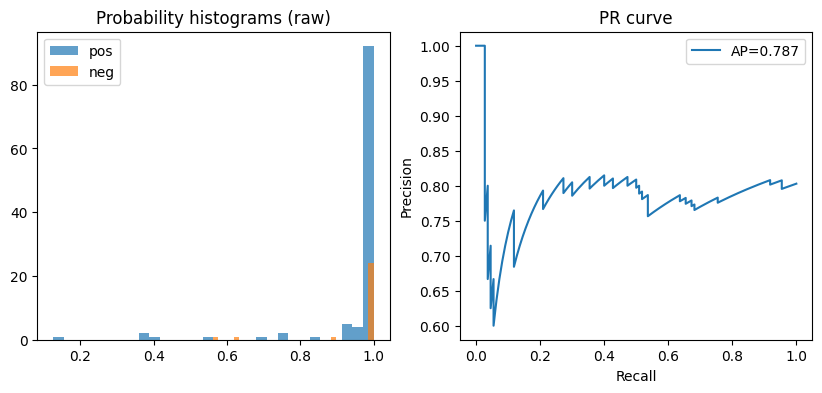

ROC AUC: 0.45185185185185184


In [85]:
# diagnostics: prob hist, class-wise distributions, PR curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# probs_test, y_test already available
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(probs_test[y_test==1], bins=30, alpha=0.7, label='pos')
plt.hist(probs_test[y_test==0], bins=30, alpha=0.7, label='neg')
plt.title('Probability histograms (raw)')
plt.legend()

plt.subplot(1,2,2)
precision, recall, thr = precision_recall_curve(y_test, probs_test)
ap = average_precision_score(y_test, probs_test)
plt.plot(recall, precision, label=f'AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve'); plt.legend()
plt.show()

print('ROC AUC:', roc_auc_score(y_test, probs_test))


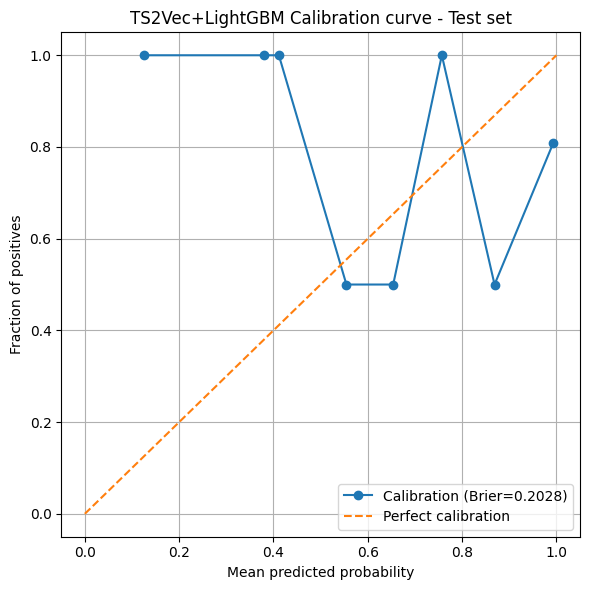

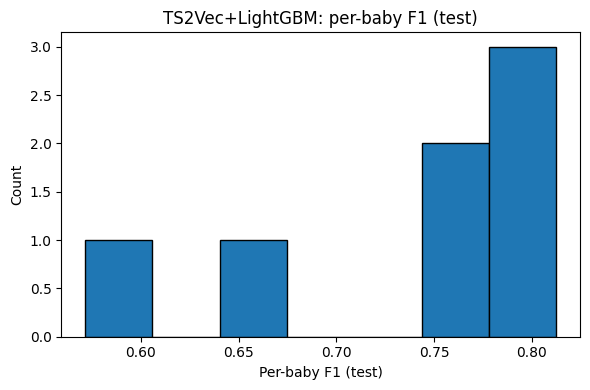

In [90]:
# Calibration curve and per-baby F1 histogram
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, probs_test, n_bins=10)
brier = brier_score_loss(y_test, probs_test)
plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'Calibration (Brier={brier:.4f})')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('TS2Vec+LightGBM Calibration curve - Test set')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ts2vec_calibration_curve_test.png', dpi=200)
plt.show()

if not per_baby_df.empty:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_df['f1'].dropna(), bins=min(20, len(per_baby_df)), edgecolor='black')
    plt.xlabel('Per-baby F1 (test)')
    plt.ylabel('Count')
    plt.title('TS2Vec+LightGBM: per-baby F1 (test)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'ts2vec_per_baby_f1_hist.png', dpi=200)
    plt.show()

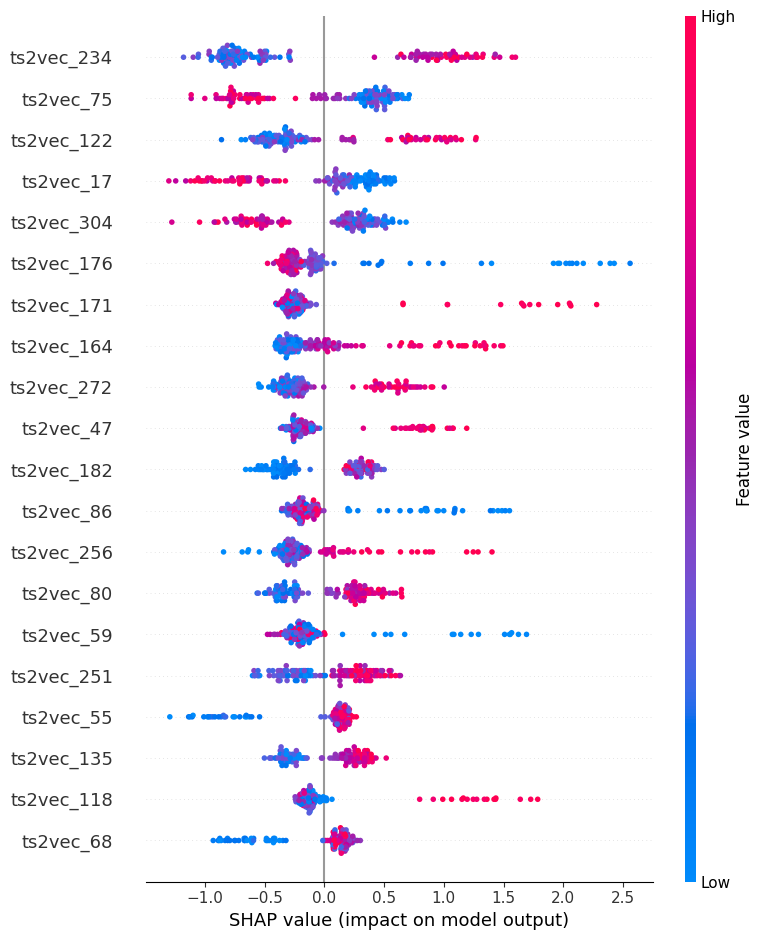

<Figure size 640x480 with 0 Axes>

In [88]:
# SHAP explanation (use DataFrame with named columns for readability)
if shap is not None:
    try:
        n_emb = emb_train.shape[1]
        emb_names = [f'ts2vec_{i}' for i in range(n_emb)]
        onehot_names = []
        try:
            onehot_step = preprocessor.transformers_[1][1].named_steps.get('onehot')
            if onehot_step is not None:
                onehot_names = list(onehot_step.get_feature_names_out(cat_features))
        except Exception:
            onehot_names = []
        feat_names = emb_names + numeric_features + onehot_names
        if len(feat_names) != X_test_all.shape[1]:
            # pad
            extra = X_test_all.shape[1] - len(feat_names)
            feat_names += [f'extra_{i}' for i in range(extra)]
        X_test_all_df = pd.DataFrame(X_test_all, columns=feat_names)
        explainer = shap.TreeExplainer(clf)
        shap_vals = explainer(X_test_all_df)
        shap.summary_plot(shap_vals, X_test_all_df, show=True)
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'ts2vec_shap_summary.png', dpi=200)
    except Exception as e:
        print('SHAP explanation failed:', e)
else:
    print('shap not installed; skip SHAP explanation')

In [89]:
# %% [markdown]
# Notes
# - This script uses the official TS2Vec implementation interface (`TS2Vec.fit` and `TS2Vec.encode`) as
#   provided in the repository and PyPI package. See README for details. citeturn2view0turn0search2
# - Pretraining on all sequences includes the test set (unsupervised). If you prefer stricter experimental
#   protocol, restrict pretraining to train+val only.
# - Tune `repr_dims`, TS2Vec hyperparameters, and LightGBM parameters to improve downstream performance.
# - If TS2Vec `device` argument raises an error on your environment, try passing `device='cpu'` or an integer GPU id.